## Pre-processing and Understanding Gym 
This is to prepare for AI Playing Mario

### Environment Preparation
See below.

### Numpy version error

When I started - I faced an from **NumPy 2.x incompatibility** with the older Mario/Gym/NES stack. It’s a known issue with `gym-super-mario-bros`/Mario-style environments and NumPy 2.x. ([GitHub][1])


[1]: https://github.com/Kautenja/gym-super-mario-bros/issues/135?utm_source=chatgpt.com "OverflowError: Python integer 1024 out of bounds for uint8"


### Step 1: Creating a new environment
At this point, I decided to **create a dedicated `mario` environment**. Cleaner and safer.

You may use Python 3.10 or 3.11, with NumPy below version 2:

```bash
conda create -n mario python=3.10 -y
conda activate mario

python -m pip install "numpy<2"
python -m pip install gym-super-mario-bros nes-py
python -m pip install gymnasium opencv-python matplotlib jupyter ipykernel
```

Then add it to Jupyter:

```bash
python -m ipykernel install --user --name mario --display-name "Python (mario)"
```

Then in Jupyter, choose kernel:

```text
Python (mario)
```

### Step 2: Test:

```python
import numpy as np
print(np.__version__)

import gym_super_mario_bros
env = gym_super_mario_bros.make("SuperMarioBros-1-1-v0")
obs = env.reset()

print("Mario works!")
print(type(obs))
```

I did this to keep my other conda environments clean for ADL and LLM courses and let `mario` be the experimental RL playground.


### Step 3: Create the Mario environment - Import Libraries

Open Jupyter using the mario kernel.  
Then import:


In [1]:
import gym_super_mario_bros

env = gym_super_mario_bros.make("SuperMarioBros-1-1-v0")

print(env)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
F:\CondaData\.conda\envs\mario\lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment SuperMarioBros-1-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(


<TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<SuperMarioBrosEnv<SuperMarioBros-1-1-v0>>>>>>


F:\CondaData\.conda\envs\mario\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
F:\CondaData\.conda\envs\mario\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


### Step 4: inspect action space and observation space

In [2]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)

Observation space: Box(0, 255, (240, 256, 3), uint8)
Action space: Discrete(256)
Number of actions: 256


### Step 5: wrap Mario with JoypadSpace

In [3]:
from nes_py.wrappers import JoypadSpace
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT

env = JoypadSpace(env, SIMPLE_MOVEMENT)

print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)
print("Actions:", SIMPLE_MOVEMENT)

Action space: Discrete(7)
Number of actions: 7
Actions: [['NOOP'], ['right'], ['right', 'A'], ['right', 'B'], ['right', 'A', 'B'], ['A'], ['left']]


### Step 6: reset the environment and inspect the first frame

In [4]:
state = env.reset()

print(type(state))
print(state.shape)
print(state.dtype)
print(state.min(), state.max())

<class 'numpy.ndarray'>
(240, 256, 3)
uint8
0 252


### Step 7: display the first frame

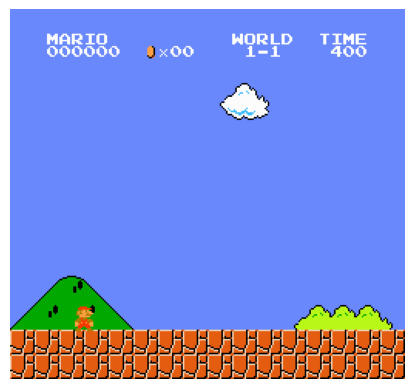

In [5]:
import matplotlib.pyplot as plt # if not already imported

plt.imshow(state)
plt.axis("off")
plt.show()

In [6]:
action = 1   # move right

next_state, reward, done, info = env.step(action)

print(next_state.shape)
print("Reward:", reward)
print("Done:", done)

(240, 256, 3)
Reward: 0.0
Done: False


F:\CondaData\.conda\envs\mario\lib\site-packages\gym\utils\passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
F:\CondaData\.conda\envs\mario\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):


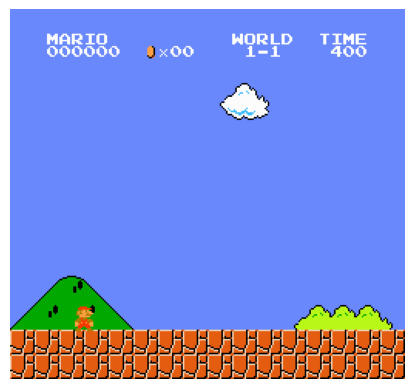

In [7]:
plt.imshow(next_state)
plt.axis("off")
plt.show()

## No Change
So, we will skip 4 frames

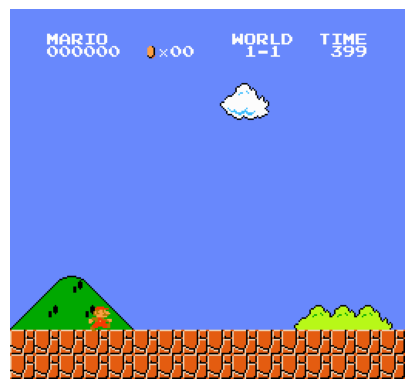

In [8]:
state = env.reset()

for _ in range(20):
    state, reward, done, info = env.step(1)   # right

plt.imshow(state)
plt.axis("off")
plt.show()

### Step 8: convert one frame to grayscale

Original shape: (240, 256, 3)
Gray shape: (240, 256)
Gray dtype: uint8
Gray min/max: 0 252


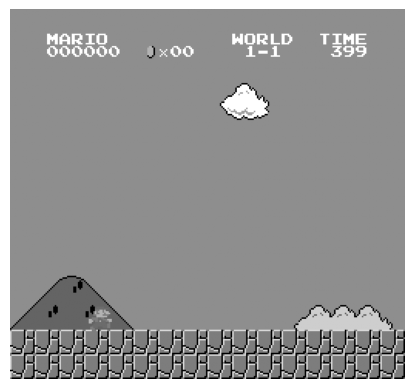

In [9]:
import cv2
import matplotlib.pyplot as plt

gray = cv2.cvtColor(state, cv2.COLOR_RGB2GRAY)

print("Original shape:", state.shape)
print("Gray shape:", gray.shape)
print("Gray dtype:", gray.dtype)
print("Gray min/max:", gray.min(), gray.max())

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

### Step 9: Resize

Gray shape: (240, 256)
Resized shape: (84, 84)
Resized dtype: uint8
Resized min/max: 0 252


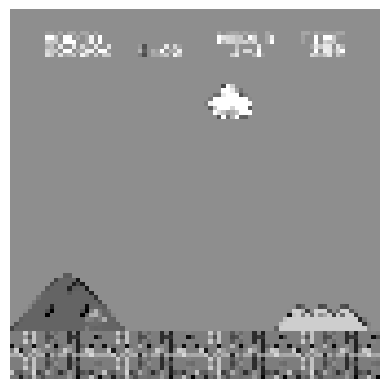

In [10]:
resized = cv2.resize(gray, (84, 84))

print("Gray shape:", gray.shape)
print("Resized shape:", resized.shape)
print("Resized dtype:", resized.dtype)
print("Resized min/max:", resized.min(), resized.max())

plt.imshow(resized, cmap="gray")
plt.axis("off")
plt.show()

### Step 10: compare shapes directly

In [11]:
print("Original grayscale pixels:", gray.shape[0] * gray.shape[1])
print("Resized pixels:", resized.shape[0] * resized.shape[1])
print("Reduction:", 1 - (resized.shape[0] * resized.shape[1]) / (gray.shape[0] * gray.shape[1]))

Original grayscale pixels: 61440
Resized pixels: 7056
Reduction: 0.88515625


### Step 11: create a reusable preprocessing function

In [12]:
# Step 11: create a reusable preprocessing function
def preprocess_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84))
    return resized

(84, 84)
uint8


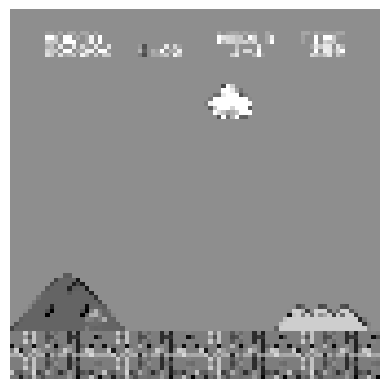

In [13]:
# Testing
processed = preprocess_frame(state)

print(processed.shape)
print(processed.dtype)

plt.imshow(processed, cmap="gray")
plt.axis("off")
plt.show()

### Step 12: normalize the frame

In [15]:
# Step 12: normalize the frame
# Right now pixels are 0–255. Neural networks prefer smaller values, usually 0–1.
# Modify the function:
def preprocess_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84))
    normalized = resized / 255.0
    return normalized

In [16]:
# test
processed = preprocess_frame(state)

print(processed.shape)
print(processed.dtype)
print(processed.min(), processed.max())

(84, 84)
float64
0.0 0.9882352941176471


## Overview of Steps so far

You've now built, by hand, the first half of what the wrapper will eventually do.

Let's pause for a second and reflect on what happened:

| Stage         | Shape         | Type    | Range |
| ------------- | ------------- | ------- | ----- |
| Raw NES frame | (240, 256, 3) | uint8   | 0–255 |
| Grayscale     | (240, 256)    | uint8   | 0–255 |
| Resized       | (84, 84)      | uint8   | 0–255 |
| Normalized    | (84, 84)      | float64 | 0–1   |

The neural network will eventually receive something much closer to:

```text
(4, 84, 84)
```

instead of

```text
(240, 256, 3)
```

which is dramatically smaller.

---

# Step 13: Understand why frame stacking is needed

Before we implement it, let's prove to ourselves that a single frame is insufficient.
We'll run:


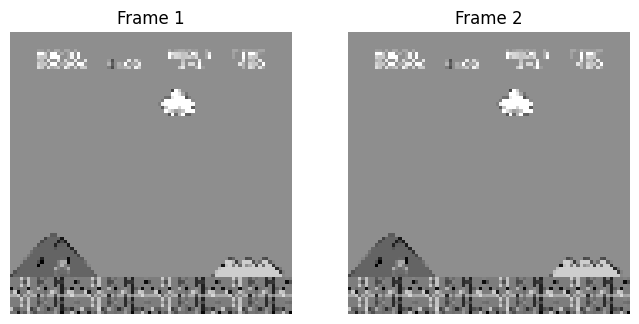

In [17]:
state1 = env.reset()

for _ in range(4):
    state2, reward, done, info = env.step(1)  # move right

frame1 = preprocess_frame(state1)
frame2 = preprocess_frame(state2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(frame1, cmap="gray")
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(frame2, cmap="gray")
plt.title("Frame 2")
plt.axis("off")

plt.show()

## Step 14: compare frames after more movement


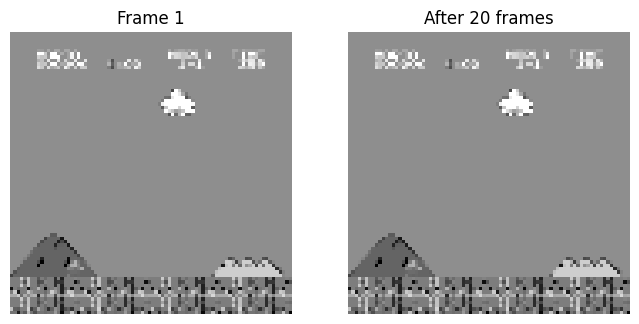

In [18]:
state1 = env.reset()

for _ in range(20):
    state2, reward, done, info = env.step(1)  # move right

frame1 = preprocess_frame(state1)
frame2 = preprocess_frame(state2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(frame1, cmap="gray")
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(frame2, cmap="gray")
plt.title("After 20 frames")
plt.axis("off")

plt.show()


### Step 15: check whether the arrays are actually different

In [19]:
print("Same shape:", state1.shape == state2.shape)

import numpy as np

print("Exactly equal:", np.array_equal(state1, state2))

print("Number of different pixels:",
      np.sum(state1 != state2))

Same shape: True
Exactly equal: True
Number of different pixels: 0


### Problem / Issue
state1 and state2 are the same underlying array/object, so when the environment advances, state1 gets overwritten too.

## Step 16: use .copy() to freeze the first frame

In [20]:
state1 = env.reset().copy()

for _ in range(20):
    state2, reward, done, info = env.step(1)

state2 = state2.copy()

print("Exactly equal:", np.array_equal(state1, state2))
print("Number of different pixels:", np.sum(state1 != state2))

Exactly equal: False
Number of different pixels: 752


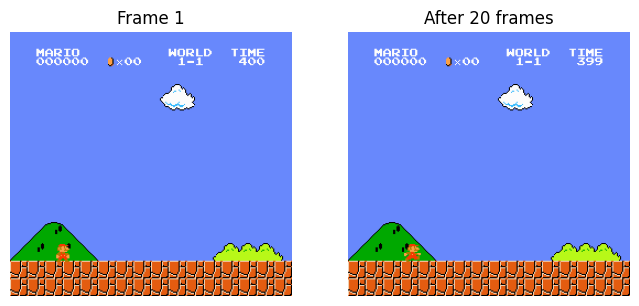

In [21]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(state1)
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(state2)
plt.title("After 20 frames")
plt.axis("off")

plt.show()

## Step 17: Compare Processed Frames

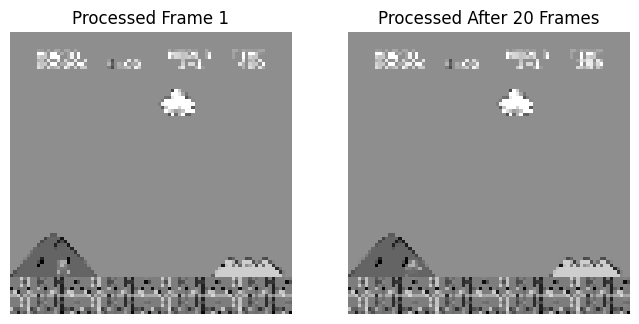

Frame 1 shape: (84, 84)
Frame 2 shape: (84, 84)
Frame 1 dtype: float64
Frame 2 dtype: float64


In [22]:
frame1 = preprocess_frame(state1)
frame2 = preprocess_frame(state2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(frame1, cmap="gray")
plt.title("Processed Frame 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(frame2, cmap="gray")
plt.title("Processed After 20 Frames")
plt.axis("off")

plt.show()

print("Frame 1 shape:", frame1.shape)
print("Frame 2 shape:", frame2.shape)
print("Frame 1 dtype:", frame1.dtype)
print("Frame 2 dtype:", frame2.dtype)

In [23]:
stacked_frames = np.stack([frame1, frame1, frame1, frame2], axis=0)

print(stacked_frames.shape)

(4, 84, 84)


We have now reached the point where Mario starts looking like a real Deep Q-Network project.

### Quick reflection

So far, we have:

1. Created a working Mario environment.
2. Reduced the action space from **256 → 7** actions.
3. Inspected the raw observations.
4. Converted frames to grayscale.
5. Resized frames from **240×256 → 84×84**.
6. Normalized pixel values to **0–1**.
7. Discovered and fixed the emulator buffer issue using `.copy()`.
8. Built a **4-frame stack**:

```text
(4, 84, 84)
```

This is essentially the same representation used in the original Atari DQN work.

---

## Step 19: Understand what the stack represents

Before writing any more code, let's inspect the stack.

We'll run:


```

### What we should expect

Right now we built:

```python
np.stack([frame1, frame1, frame1, frame2], axis=0)
```

so:

```text
Frame 1 = same
Frame 2 = same
Frame 3 = same
Frame 4 = moved
```

This is not a real frame stack yet—it's just a demonstration.

But it helps visualize the concept.

---

### Why stacking works

A single frame tells us:

```text
Mario is here.
```

A stack tells us:

```text
Mario was here.
Mario was here.
Mario was here.
Mario is now here.
```

From that, the CNN can infer:

* movement direction
* speed
* jumping
* falling
* enemy movement

without us explicitly calculating velocity.

---

When we run the visualization andwe'll see whether the four panels appear as expected (three identical + one moved).

After that, we'll build a **real frame stack** by collecting 4 consecutive observations from the environment. That will be the final preprocessing step before introducing PyTorch.


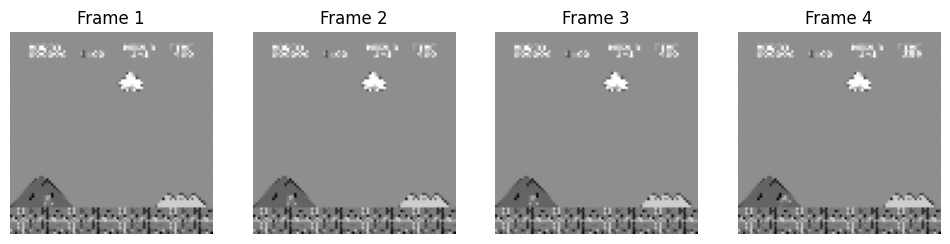

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(stacked_frames[i], cmap="gray")
    axes[i].set_title(f"Frame {i+1}")
    axes[i].axis("off")

plt.show()

## Step 20: build a real 4-frame stack

In [25]:
state = env.reset().copy()

frames = []

for _ in range(4):
    state, reward, done, info = env.step(1)  # move right
    processed = preprocess_frame(state.copy())
    frames.append(processed)

real_stack = np.stack(frames, axis=0)

print(real_stack.shape)

(4, 84, 84)


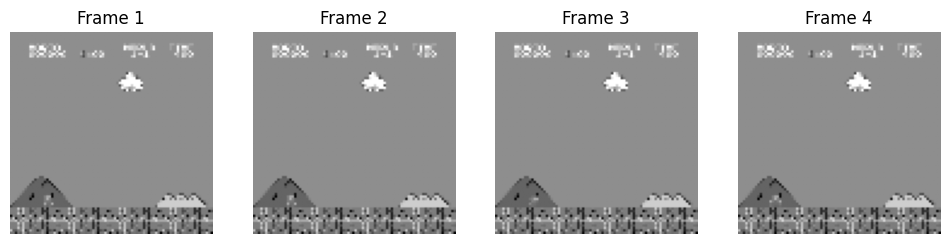

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(real_stack[i], cmap="gray")
    axes[i].set_title(f"Frame {i+1}")
    axes[i].axis("off")

plt.show()

## Step 21: add frame skip

In [28]:
STACK_SIZE = 4
FRAME_SKIP = 4

In [29]:
frames = []

for _ in range(STACK_SIZE):

    for _ in range(FRAME_SKIP):
        state, reward, done, info = env.step(1)

    processed = preprocess_frame(state.copy())
    frames.append(processed)

stack = np.stack(frames, axis=0)

### A useful mental model

Think of:

```text
FRAME_SKIP
```

as the **time between photographs**.

And:

```text
STACK_SIZE
```

as the **number of photographs we keep**.

For example:

```text
STACK_SIZE = 4
FRAME_SKIP = 1
```

gives:

```text
t-3, t-2, t-1, t
```

Very little movement between frames.

While:

```text
STACK_SIZE = 4
FRAME_SKIP = 4
```

gives roughly:

```text
t-12, t-8, t-4, t
```

Much more visible motion.

---

### Learning checkpoint

So far, we have manually recreated most of the preprocessing pipeline:

```text
Raw Frame
    ↓
Grayscale
    ↓
Resize (84×84)
    ↓
Normalize
    ↓
Frame Skip
    ↓
Frame Stack
    ↓
(4,84,84)
```

This is the exact input shape the CNN will eventually receive.

My recommendation is that the **next step should not be more environment code**.

The next step should be:

**Build the CNN and pass one `(4,84,84)` stack through it.**

